In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import recall_score, precision_score, classification_report, ConfusionMatrixDisplay

##### 1. Seçtiğiniz veri setini pandas ile okuyun veya uygun şekilde oluşturun. Veri setinin hangi problemi çözdüğünü kısaca açıklayın.

In [2]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

##### Problem: Bir kişinin inme geçirip geçirmeyeceğini tahmin etmek

##### 2. Hedef değişkeni belirleyin. Problemin sınıflandırma mı regresyon mu olduğunu açıkça belirtin.

In [3]:
y = df["stroke"]

In [4]:
y.value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

##### Binary classification

##### 3.  Veri setinin ilk satırlarını, satır-sütun sayısını, veri tiplerini ve temel istatistiklerini inceleyin.

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [6]:
df.shape

(5110, 12)

In [7]:
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [8]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [9]:
df.drop("id", axis= 1, inplace= True)

##### 4. Eksik değer kontrolü yapın. Eksik değer varsa uygun şekilde doldurun veya temizleyin.

In [10]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [11]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [12]:
df.isna().sum().sum()

np.int64(0)

##### 5. Kategorik değişkenleri uygun encoding yöntemiyle sayısal forma dönüştürün.

In [13]:
encoding_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

In [14]:
df = pd.get_dummies(data= df, columns= encoding_cols, drop_first= True)

##### 6. Aykırı değerleri inceleyin. Gerekli gördüğünüz durumlarda silme, sınırlandırma veya yorumlama yaklaşımı kullanın.

In [15]:
outlier_cols = ["age", "avg_glucose_level", "bmi"]

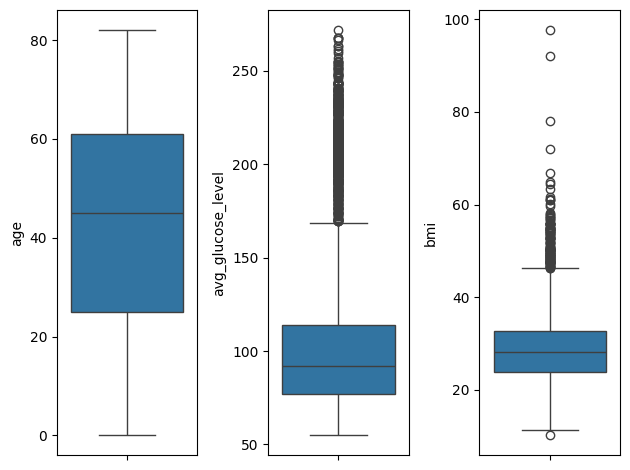

In [16]:
i = 0

for i, column in enumerate(outlier_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data= df[column])
    i += 1

plt.tight_layout()
plt.show()

In [17]:
for column in outlier_cols:
    q3 = df[column].quantile(0.75)
    q1 = df[column].quantile(0.25)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}: {len(outliers)}")

age: 0
avg_glucose_level: 627
bmi: 126


##### Tıbbi veriseti olduğu için aykırı glucose ve bmi değerleri stroke tahmininde bilgi taşıyabileceği için silinmedi

##### 7.  Gerekli modeller için sayısal değişkenlerde ölçekleme uygulayın.

In [18]:
scaling_cols = outlier_cols

In [19]:
scaler = RobustScaler()

df[scaling_cols] = scaler.fit_transform(df[scaling_cols])

##### Aykırı glucose ve bmi değerleri silinmediği için Robust Scaler tercih edildi

##### 8.  En az 2 tane anlamlı öznitelik üretin.

In [20]:
df["bmi_group"] = pd.cut(
    x= df["bmi"],
    bins= [0, 18.5, 25, 30, 100],
    labels= ["underweight", "normal", "overweight", "obese"]
)

In [21]:
df = pd.get_dummies(data= df, columns= ["bmi_group"], drop_first= True)

In [22]:
df["health_risk"] = df["hypertension"] + df["heart_disease"]

##### 9. En az 1 tane öznitelik seçimi yaklaşımı uygulayın. Örnek: korelasyon analizi, feature importance, düşük varyanslı değişkenleri eleme veya Lasso tabanlı seçim.

In [23]:
corr_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi", "health_risk", "stroke"]

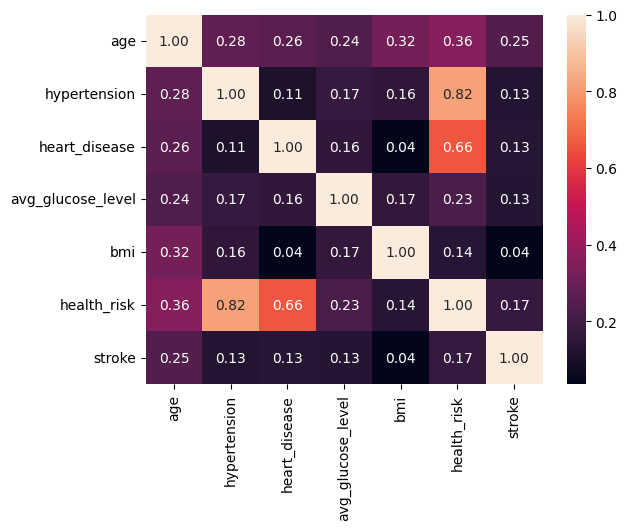

In [24]:
sns.heatmap(df[corr_cols].corr(), annot= True, fmt= ".2f")
plt.show()

In [25]:
X = df.drop("stroke", axis= 1)

In [26]:
lasso = LogisticRegression(penalty= "l1", solver= "liblinear", random_state= 42).fit(X, y)

In [27]:
pd.Series(lasso.coef_[0], index= X.columns).sort_values()

work_type_Self-employed          -0.255762
ever_married_Yes                 -0.193281
smoking_status_never smoked      -0.184674
heart_disease                     0.000000
gender_Other                      0.000000
work_type_children                0.000000
bmi                               0.000000
gender_Male                       0.000000
smoking_status_formerly smoked    0.000000
work_type_Never_worked            0.000000
bmi_group_overweight              0.000000
bmi_group_normal                  0.000000
bmi_group_obese                   0.000000
Residence_type_Urban              0.056981
work_type_Private                 0.071450
smoking_status_smokes             0.081024
hypertension                      0.085011
avg_glucose_level                 0.149308
health_risk                       0.300192
age                               2.567493
dtype: float64

In [28]:
df.drop(["bmi", "bmi_group_overweight", "bmi_group_normal"], axis= 1, inplace= True)

##### Korelasyon analizinde stroke ile korelasyonu düşük ve Lasso tabanlı özellik seçiminde katsayısı 0 olduğu için BMI ile BMI dan türetilen sütunlar silindi

##### 10. Veriyi train, validation ve test kümelerine ayırın. Sınıflandırma problemi kullanıyorsanız mümkünse stratify kullanın.

In [29]:
X = df.drop("stroke", axis= 1)
y = df["stroke"]

In [30]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size= 0.1, random_state= 42, stratify= y)

In [31]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size= 0.1, random_state= 42, stratify= y_train_val)

In [32]:
X_train.shape, X_test.shape, X_val.shape

((4139, 17), (511, 17), (460, 17))

##### 11.  En az 3 farklı model eğitin.

In [33]:
logistic_reg = LogisticRegression(random_state= 42, class_weight= "balanced").fit(X_train, y_train)

In [34]:
knn = KNeighborsClassifier().fit(X_train, y_train)

In [35]:
svm = SVC(random_state= 42, class_weight= "balanced").fit(X_train, y_train)

##### 12. Validation sonuçlarına göre modelleri karşılaştırın. Probleminize uygun metrikleri kullanın.

In [36]:
y_pred_lr = logistic_reg.predict(X_val)

In [37]:
recall_score(y_val, y_pred_lr)

0.8636363636363636

In [38]:
precision_score(y_val, y_pred_lr)

0.15833333333333333

In [39]:
y_pred_knn = knn.predict(X_val)

In [40]:
recall_score(y_val, y_pred_knn)

0.0

In [41]:
precision_score(y_val, y_pred_knn)

0.0

In [42]:
y_pred_svm = svm.predict(X_val)

In [43]:
recall_score(y_val, y_pred_svm)

0.6818181818181818

In [44]:
precision_score(y_val, y_pred_svm)

0.13392857142857142

##### 13. Seçtiğiniz en iyi model için Grid Search veya Random Search ile basit bir hiperparametre ayarlama çalışması yapın.

In [45]:
logistic_reg_params = {
    "C": [0.1, 1, 10],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs", "liblinear"]
}

In [46]:
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

In [47]:
grid_model = GridSearchCV(
    estimator= LogisticRegression(random_state= 42),
    param_grid= logistic_reg_params,
    scoring= "recall",
    cv= cv,
).fit(X_train, y_train)

##### 14. En iyi modeli test verisi üzerinde değerlendirin. Sınıflandırma için confusion matrix, accuracy, precision, recall ve F1-score; regresyon için MAE, MSE, RMSE ve R² değerlerini yazdırın.

In [48]:
grid_model.best_score_

np.float64(0.8015853658536585)

In [49]:
best_model = grid_model.best_estimator_

In [50]:
y_pred = best_model.predict(X_test)

In [51]:
recall_score(y_test, y_pred)

0.68

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.74      0.85       486
           1       0.12      0.68      0.20        25

    accuracy                           0.74       511
   macro avg       0.55      0.71      0.53       511
weighted avg       0.94      0.74      0.81       511



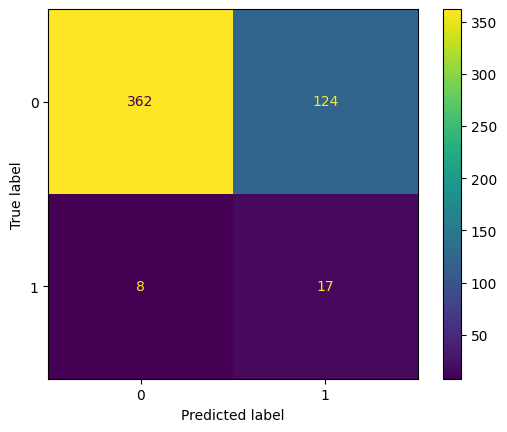

In [53]:
ConfusionMatrixDisplay.from_estimator(estimator= best_model, X= X_test, y= y_test)
plt.show()

##### 15. Model sonucunu kısaca yorumlayın. Hangi model daha iyi oldu, hangi değişkenler önemli görünüyor ve modelin sınırlılıkları neler olabilir?

##### Validation sonuçlarına göre Logistic Regression modeli diğer modellere göre daha yüksek recall değeri elde ettiği için hiperparametre optimizasyonu yapıldı. Test verisinde %68 lik recall ve %12 lik precision skorları modelin stroke vakalarını yakalayabildiğini ancak yanlış pozitif tahminlerinin de fazla olduğunu göstermektedir. Verisetindeki sınıf dengesizliği bunun en başlıca sebeplerindendir. 

##### 16. En iyi model için basit bir açıklanabilirlik yorumu ekleyin. Örneğin feature importance, katsayı yorumu, SHAP veya LIME çıktısı kullanabilirsiniz.

In [54]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": best_model.coef_[0]
})

In [55]:
coef_df

,feature,coef
0,age,2.569981
1,hypertension,0.250040
2,heart_disease,0.113165
3,avg_glucose_level,0.171941
4,gender_Male,-0.264029
5,gender_Other,-0.006064
6,ever_married_Yes,-0.114571
7,work_type_Never_worked,-0.032232
8,work_type_Private,-0.114353
9,work_type_Self-employed,-0.231482


In [56]:
coef_df["coef_abs"] = coef_df["coef"].abs()

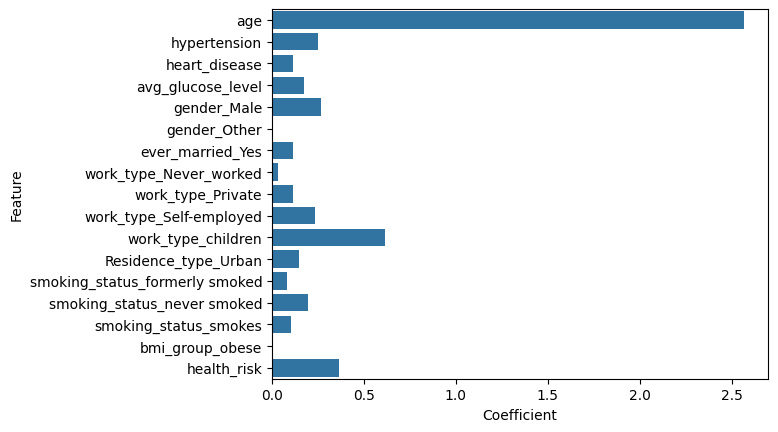

In [57]:
sns.barplot(data= coef_df, x= "coef_abs", y= "feature")
plt.xlabel("Coefficient"),
plt.ylabel("Feature"),
plt.show()